In [1]:
import copy

import scipy.io as sio
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import random

data = sio.loadmat('Xtrain.mat')
print(data['Xtrain'].shape)

series = np.array(data['Xtrain']).squeeze().astype(np.float32)
print(series.shape)
print(series[:10])

(1000, 1)
(1000,)
[ 86. 141.  95.  41.  22.  21.  32.  72. 138. 111.]


In [2]:
scaler = StandardScaler()
series_scaled = scaler.fit_transform(series.reshape(-1, 1)).squeeze()
print(series_scaled[:10])
print("Scaled shape:", series_scaled.shape)

[ 0.55720156  1.7311113   0.74929583 -0.40327    -0.8088024  -0.83014625
 -0.59536433  0.25838816  1.6670799   1.0907968 ]
Scaled shape: (1000,)


In [3]:
class TimeSeriesDataset(Dataset):
    def __init__(self, series, window_size):
        self.series = series
        self.window_size = window_size

    def __len__(self):
        return len(self.series) - self.window_size

    def __getitem__(self, idx):
        x = self.series[idx : idx + self.window_size]
        y = self.series[idx + self.window_size]

        # GRU input shape: [seq_len, input_size]
        x = torch.tensor(x, dtype=torch.float32).unsqueeze(-1)
        y = torch.tensor(y, dtype=torch.float32)

        return x, y

In [4]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, output_size=1, dropout=0.0):
        super(GRUModel, self).__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, hidden = self.gru(x)

        last_out = out[:, -1, :]

        y_pred = self.fc(last_out)

        return y_pred.squeeze(-1)

In [5]:
train_ratio = 0.8
split_idx = int(len(series_scaled) * train_ratio)

train_series = series_scaled[:split_idx]
val_series = series_scaled[split_idx:]

print("Train length:", len(train_series))
print("Val length:", len(val_series))

Train length: 800
Val length: 200


In [6]:
def train_gru(
    train_series,
    val_series,
    seed,
    window_size=25,
    hidden_size=64,
    num_layers=1,
    lr=0.001,
    batch_size=64,
    epochs=100
):

    device = torch.device("cpu")
    print("Using device:", device)

    train_dataset = TimeSeriesDataset(train_series, window_size)
    val_dataset = TimeSeriesDataset(val_series, window_size)

    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,generator=g)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = GRUModel(
        input_size=1,
        hidden_size=hidden_size,
        num_layers=num_layers,
        output_size=1
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float("inf")
    best_model_state = None

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * x_batch.size(0)

        avg_train_loss = total_train_loss / len(train_dataset)

        model.eval()
        total_val_loss = 0.0

        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                y_pred = model(x_batch)
                loss = criterion(y_pred, y_batch)

                total_val_loss += loss.item() * x_batch.size(0)

        avg_val_loss = total_val_loss / len(val_dataset)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_state)

    return model, train_losses, val_losses, best_val_loss

In [27]:
def recursive_forecast(model, history_scaled, window_size, steps=200):
    device = next(model.parameters()).device
    model.eval()

    history = list(history_scaled.copy())
    predictions = []

    with torch.no_grad():
        for _ in range(steps):
            x = np.array(history[-window_size:], dtype=np.float32)

            x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)

            next_pred = model(x_tensor).item()

            predictions.append(next_pred)
            history.append(next_pred)

    return np.array(predictions)

In [35]:
window_sizes = range(15,30)
learning_rates = [0.0001, 0.001, 0.01, 0.1]
seeds = [42, 1, 2]
grid_results = {}
total = len(window_sizes) * len(learning_rates)
counter = 0

for ws in window_sizes:
    for lr in learning_rates:
        counter += 1
        print("=" * 60)
        print(f"[{counter}/{total}] window_size={ws}, lr={lr}")
        print("=" * 60)

        recursive_mses = []
        for seed in seeds:
            random.seed(seed)
            np.random.seed(seed)
            torch.manual_seed(seed)

            model_tmp, _, _, single_step_val_loss = train_gru(
                train_series=train_series,
                val_series=val_series,
                window_size=ws,
                hidden_size=64,
                num_layers=1,
                lr=lr,
                batch_size=64,
                epochs=80
            )
            recursive_steps = len(val_series)
            recursive_preds = recursive_forecast(
                model=model_tmp,
                history_scaled=train_series,
                window_size=ws,
                steps=recursive_steps
            )
            recursive_mse = np.mean((recursive_preds - val_series) ** 2)
            recursive_mses.append(recursive_mse)
            print(f"seed={seed}, recursive_mse={recursive_mse:.6f}")
        grid_results[(ws, lr)] = {
            "recursive_mse_mean":   np.mean(recursive_mses),
            "recursive_mse_std":    np.std(recursive_mses),
            "recursive_mse":   recursive_mses
        }
        print(f"mean recursive MSE: {np.mean(recursive_mses):.6f} +/- {np.std(recursive_mses):.6f}")

[1/60] window_size=15, lr=0.0001
Using device: cpu
seed=42, recursive_mse=2.487340
Using device: cpu
seed=1, recursive_mse=2.640763
Using device: cpu
seed=2, recursive_mse=2.282445
mean recursive MSE: 2.470183 +/- 0.146785
[2/60] window_size=15, lr=0.001
Using device: cpu
seed=42, recursive_mse=0.790444
Using device: cpu
seed=1, recursive_mse=0.693371
Using device: cpu
seed=2, recursive_mse=0.718117
mean recursive MSE: 0.733977 +/- 0.041186
[3/60] window_size=15, lr=0.01
Using device: cpu
seed=42, recursive_mse=1.041414
Using device: cpu
seed=1, recursive_mse=1.022909
Using device: cpu
seed=2, recursive_mse=1.270543
mean recursive MSE: 1.111622 +/- 0.112628
[4/60] window_size=15, lr=0.1
Using device: cpu
seed=42, recursive_mse=9.090763
Using device: cpu
seed=1, recursive_mse=8.624816
Using device: cpu
seed=2, recursive_mse=0.823881
mean recursive MSE: 6.179820 +/- 3.791995
[5/60] window_size=16, lr=0.0001
Using device: cpu
seed=42, recursive_mse=2.586913
Using device: cpu
seed=1, recur

In [36]:
print(f"{'ws':>4} | {'lr':>8} | {'recursive MSE':>18}")
for (ws, lr), m in grid_results.items():
    rc = f"{m['recursive_mse_mean']:.6f} ± {m['recursive_mse_std']:.6f}"

best_params = min(grid_results, key=lambda k: grid_results[k]["recursive_mse_mean"])
best_ws, best_lr = best_params

print(f"best parameters:window_size={best_ws}, lr={best_lr}")
print(f"mean recursive MSE: {grid_results[best_params]['recursive_mse_mean']:.6f} "
      f"± {grid_results[best_params]['recursive_mse_std']:.6f}")

  ws |       lr |      recursive MSE
best parameters:window_size=15, lr=0.001
mean recursive MSE: 0.733977 ± 0.041186


In [49]:
seeds = [42,1,2]
ensemble_models = []
all_train_losses = []
all_val_losses = []
for seed in seeds:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    model, train_losses, val_losses, best_val_loss = train_gru(
        train_series=train_series,
        val_series=val_series,
        seed=seed,
        window_size=15,
        hidden_size=64,
        num_layers=1,
        lr=0.001,
        batch_size=64,
        epochs=100
    )

    ensemble_models.append(model)
    all_train_losses.append(train_losses)
    all_val_losses.append(val_losses)
    print(f"seed={seed}, val_loss={best_val_loss:.6f}")

Using device: cpu
seed=42, val_loss=0.000861
Using device: cpu
seed=1, val_loss=0.000947
Using device: cpu
seed=2, val_loss=0.000999


[1.00126373 0.89894498 0.74543788 0.47642756 0.2954505  0.2291074
 0.19561335 0.17507577 0.15945559 0.15297289 0.14341679 0.13143619
 0.1239565  0.11646672 0.11116694 0.10599939 0.09922839 0.09891769
 0.08862707 0.08850962 0.08536774 0.07929416 0.08296189 0.07911886
 0.07119044 0.07053068 0.06987225 0.07015739 0.06766286 0.05999724
 0.06087629 0.05819546 0.05890415 0.06813083 0.06084253 0.06314309
 0.05496053 0.05375581 0.04939342 0.05106672 0.04834538 0.04596672
 0.04715987 0.04567179 0.04576847 0.04317465 0.04617612 0.04116397
 0.04130118 0.04217785 0.04354086 0.04173304 0.03962293 0.03817325
 0.03743946 0.03610366 0.03689535 0.03488543 0.03558055 0.03619295
 0.0360568  0.03538929 0.03274651 0.03341109 0.03282544 0.03523184
 0.03206914 0.03185337 0.03179794 0.03299507 0.03056482 0.02942895
 0.03076858 0.02827676 0.02806003 0.02663167 0.02620825 0.02674754
 0.0263132  0.02752846 0.02713629 0.02722791 0.02664748 0.03398244
 0.02776002 0.02524827 0.02427869 0.02446545 0.0230826  0.02152

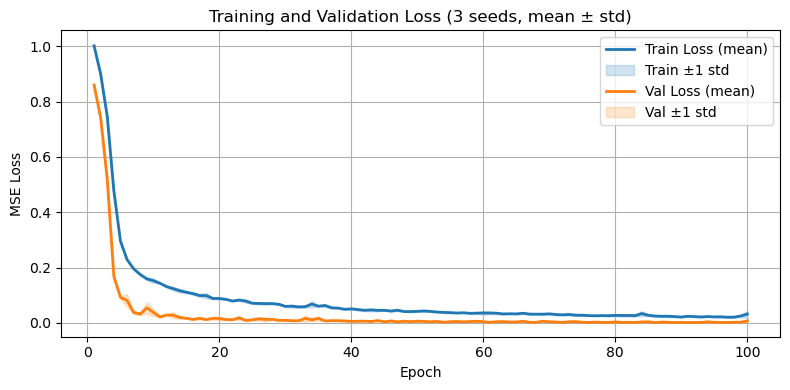

In [50]:
train_arr = np.array([l for l in all_train_losses])
val_arr   = np.array([l for l in all_val_losses])

train_mean, train_std = train_arr.mean(0), train_arr.std(0)
val_mean,   val_std   = val_arr.mean(0),   val_arr.std(0)

print(train_mean)
print(val_mean)
epochs = np.arange(1, 101)

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_mean, label='Train Loss (mean)', color='tab:blue', linewidth=2)
plt.fill_between(epochs, train_mean - train_std, train_mean + train_std,
                 alpha=0.2, color='tab:blue', label='Train ±1 std')

plt.plot(epochs, val_mean, label='Val Loss (mean)', color='tab:orange', linewidth=2)
plt.fill_between(epochs, val_mean - val_std, val_mean + val_std,
                 alpha=0.2, color='tab:orange', label='Val ±1 std')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title(f'Training and Validation Loss ({len(seeds)} seeds, mean ± std)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [44]:
def predict_one_step(model, series_scaled, window_size):
    device = next(model.parameters()).device
    model.eval()

    preds = []
    targets = []

    with torch.no_grad():
        for i in range(len(series_scaled) - window_size):
            x = series_scaled[i : i + window_size]
            y_true = series_scaled[i + window_size]

            x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)

            y_pred = model(x_tensor).item()

            preds.append(y_pred)
            targets.append(y_true)

    preds = np.array(preds)
    targets = np.array(targets)

    return preds, targets

In [51]:
all_val_preds_scaled = []
for model in ensemble_models:
    val_preds_scaled, val_targets_scaled = predict_one_step(
        model=model,
        series_scaled=val_series,
        window_size=15
    )
    all_val_preds_scaled.append(val_preds_scaled)
ensemble_val_preds_scaled = np.mean(all_val_preds_scaled,axis=0)
# scale back
ensemble_val_preds = scaler.inverse_transform(ensemble_val_preds_scaled.reshape(-1, 1)).squeeze()
val_targets = scaler.inverse_transform(val_series[15:].reshape(-1, 1)).squeeze()

mae = mean_absolute_error(val_targets, ensemble_val_preds)
mse = mean_squared_error(val_targets, ensemble_val_preds)

print("Validation MAE:", mae)
print("Validation MSE:", mse)

Validation MAE: 1.061787133770082
Validation MSE: 1.8142431131093515


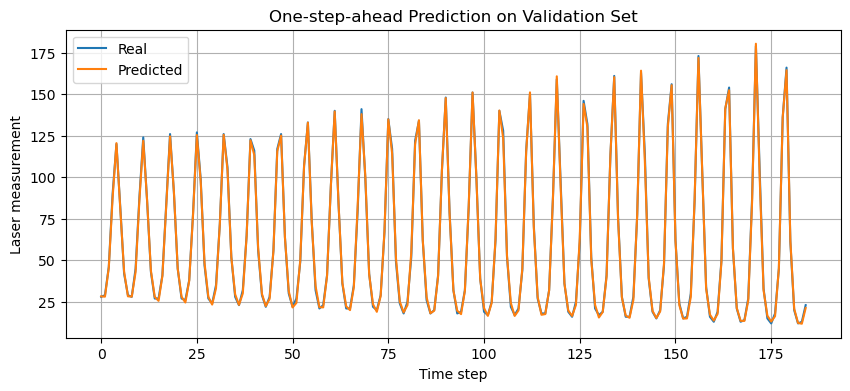

In [52]:
plt.figure(figsize=(10, 4))
plt.plot(val_targets, label="Real")
plt.plot(ensemble_val_preds, label="Predicted")
plt.xlabel("Time step")
plt.ylabel("Laser measurement")
plt.title("One-step-ahead Prediction on Validation Set")
plt.legend()
plt.grid(True)
plt.show()

In [53]:
all_preds_scaled = []
for model in ensemble_models:
    future_preds_scaled = recursive_forecast(
        model=model,
        history_scaled=series_scaled[:800],
        steps=200,
        window_size=15,
    )
    all_preds_scaled.append(future_preds_scaled)
ensemble_preds_scaled = np.mean(all_preds_scaled, axis=0)
ensemble_preds = scaler.inverse_transform(ensemble_preds_scaled.reshape(-1, 1)).squeeze()

mae200 = mean_absolute_error(series[800:], ensemble_preds)
mse200 = mean_squared_error(series[800:], ensemble_preds)

print(f"MAE200: {mae200:.6f}")
print(f"MSE200: {mse200:.6f}")

MAE200: 29.768010
MSE200: 1544.920507


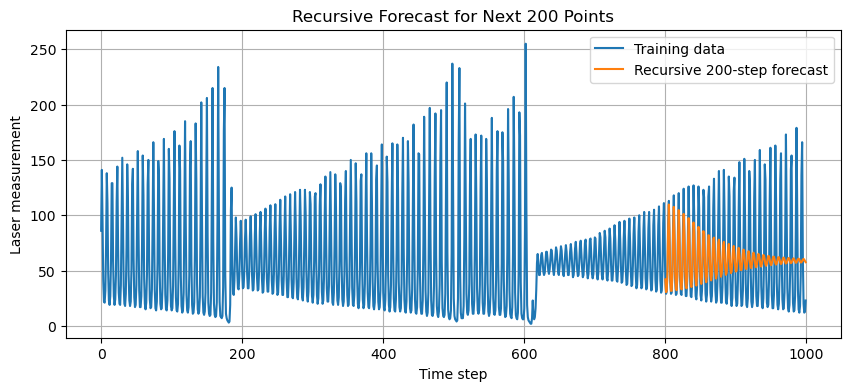

In [54]:
plt.figure(figsize=(10, 4))

plt.plot(np.arange(len(series)), series, label="Training data")
plt.plot(
    np.arange(len(series)-200, len(series)),
    ensemble_preds,
    label="Recursive 200-step forecast"
)

plt.xlabel("Time step")
plt.ylabel("Laser measurement")
plt.title("Recursive Forecast for Next 200 Points")
plt.legend()
plt.grid(True)
plt.savefig("Recursive Forecast for Next 200 Points.png")
plt.show()